## Modelling

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Read the original csv file, make a copy and make explorations
df_original = pd.read_csv("data/df_grocery_cleaned.csv")
df_grocery = df_original.copy()
# df_original.head()
# df_original.describe
# df_original.info()

In [3]:
#converts a column of pickup timestamps into just the hour of day — 
# while silently handling bad data and avoiding noisy warnings.
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    df_grocery['pickup_hour'] = pd.to_datetime(df_grocery['pickup_time'], errors='coerce').dt.hour



In [4]:
for c in df_grocery.columns:
    print(c)

order_id
agent_age
agent_rating
store_latitude
store_longitude
drop_latitude
drop_longitude
order_date
order_time
pickup_time
weather
traffic
vehicle
area
delivery_time
category
pickup_hour
weekday
week
distance
age_group
order_datetime
pickup_datetime
time_of_day
order_to_pickup_min


In [5]:
df_grocery.head(2)

,order_id,agent_age,agent_rating,store_latitude,store_longitude,drop_latitude,drop_longitude,order_date,order_time,pickup_time,...,category,pickup_hour,weekday,week,distance,age_group,order_datetime,pickup_datetime,time_of_day,order_to_pickup_min
0,uhfs888375680,35,4.0,12.311072,76.654878,12.351072,76.694878,2022-03-01,14:55:00,15:10:00,...,Grocery,15,Tuesday,9,6.218001,26-35,2022-03-01 14:55:00,2022-03-01 15:10:00,Afternoon,15.0
1,zotl583816092,32,3.5,0.000000,0.000000,0.110000,0.110000,2022-03-08,21:35:00,21:45:00,...,Grocery,21,Tuesday,10,17.297866,26-35,2022-03-08 21:35:00,2022-03-08 21:45:00,Evening,10.0


In [6]:
# df_grocery[['delivery_time', 'distance']] 

In [7]:
# Check period of the dataset
print(min(df_grocery['order_date']))
print(max(df_grocery['order_date']))

2022-02-11
2022-04-06


### Doing a Regression



How Strong Should Correlation Be for Regression?

✅ Ideal Range for Predictor–Target Correlation
- Above 0.3: Moderate correlation — worth exploring in regression.

- Above 0.5: Strong correlation — likely a good predictor.
- Above 0.7: Very strong — but watch out for multicollinearity if multiple predictors are this high.

In [8]:
# !pip install statsmodels

In [9]:
# ! conda install -c conda-forge statsmodels -y

In [10]:
import sys
print(sys.executable)


/Users/kcondeixa/opt/anaconda3/envs/amazon_delivery/bin/python


In [11]:
# !/Users/kcondeixa/opt/anaconda3/envs/amazon_delivery/bin/python -m pip install statsmodels

In [12]:
import statsmodels.api as sm
print(sm.__version__)


0.14.5


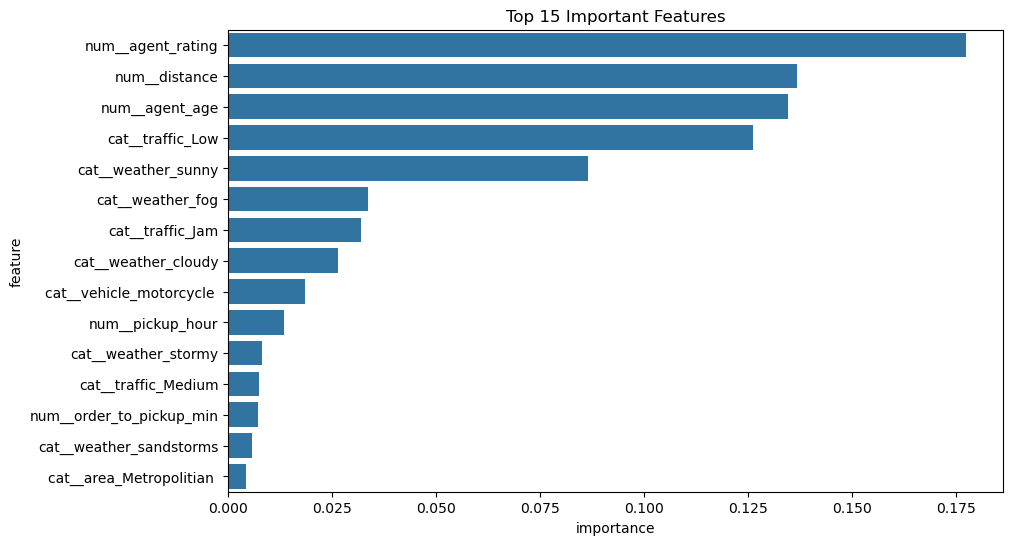

In [13]:
import statsmodels.api as sm

X = df_grocery[['agent_age', 'agent_rating', 'pickup_hour']]
y = df_grocery['delivery_time']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          delivery_time   R-squared:                       0.252
Model:                            OLS   Adj. R-squared:                  0.251
Method:                 Least Squares   F-statistic:                     300.7
Date:                Tue, 04 Nov 2025   Prob (F-statistic):          2.90e-168
Time:                        10:14:38   Log-Likelihood:                -9475.7
No. Observations:                2688   AIC:                         1.896e+04
Df Residuals:                    2684   BIC:                         1.898e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           46.8725      2.610     17.960   

In [16]:
# --- Imports ---
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- 1) Copy data ---
df = df_grocery.copy()

# --- 2) Parse pickup_time only (delivery_time stays numeric in minutes) ---
if "pickup_time" in df.columns and not np.issubdtype(df["pickup_time"].dtype, np.datetime64):
    df["pickup_time"] = pd.to_datetime(df["pickup_time"], errors="coerce")

# --- 3) Time features (no leakage) ---
df["pickup_hour"] = df["pickup_time"].dt.hour
df["is_rush_hour"] = ((df["pickup_hour"] >= 7) & (df["pickup_hour"] <= 9)) | ((df["pickup_hour"] >= 17) & (df["pickup_hour"] <= 19))
df["is_weekend"] = df["pickup_time"].dt.dayofweek.isin([5, 6])

# --- 4) Target & feature set ---
target = "delivery_time"   # already numeric minutes
y = df[target]

# Drop columns that are raw timestamps or otherwise not model-friendly
drop_cols = [c for c in ["pickup_time", "order_datetime", "pickup_datetime", target] if c in df.columns]
X = df.drop(columns=drop_cols)

# Cast likely categoricals
likely_cats = ["weekday","week","vehicle","weather","traffic","area","category","time_of_day","age_group","is_rush_hour","is_weekend"]
for col in likely_cats:
    if col in X.columns and X[col].dtype not in [bool, "category"]:
        X[col] = X[col].astype("category")

# --- 5) Preprocess ---
latlon_cols = ["store_latitude","store_longitude","drop_latitude","drop_longitude"]
numeric_features = X.select_dtypes(include=[np.number]).columns.difference(latlon_cols)
categorical_features = X.select_dtypes(include=["object","category","bool"]).columns

numeric_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])
categorical_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                             ("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocess = ColumnTransformer([("num", numeric_pipe, numeric_features),
                                ("cat", categorical_pipe, categorical_features)],
                               remainder="drop")

# --- 6) Model ---
model = Pipeline([("prep", preprocess),
                  ("rf", RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1))])

# --- 7) Train/test ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- 8) Metrics + baseline ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
y_base = np.full_like(y_test, y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_base))

mean_val, std_val, rng_val = y.mean(), y.std(), y.max() - y.min()
pct = lambda a,b: (100*a/b) if b else np.nan

print("=== Random Forest (target: delivery_time in minutes) ===")
print(f"R²: {r2:.3f} | RMSE: {rmse:.2f} min | Baseline RMSE: {baseline_rmse:.2f} min")
print(f"RMSE ≈ {pct(rmse, mean_val):.0f}% of mean ({mean_val:.2f}) | "
      f"{pct(rmse, std_val):.0f}% of std ({std_val:.2f}) | "
      f"{pct(rmse, rng_val):.0f}% of range ({rng_val:.2f})")

# Optional CV
cv = -cross_val_score(model, X, y, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1)
print(f"CV RMSE (5-fold): mean {cv.mean():.2f} ± {cv.std():.2f}")


/var/folders/xs/pmxwbppj14b4v76l4llp17n80000gp/T/ipykernel_70829/2141715496.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["pickup_time"] = pd.to_datetime(df["pickup_time"], errors="coerce")


=== Random Forest (target: delivery_time in minutes) ===
R²: 0.731 | RMSE: 4.95 min | Baseline RMSE: 9.55 min
RMSE ≈ 19% of mean (26.54) | 52% of std (9.50) | 11% of range (44.00)
CV RMSE (5-fold): mean 5.04 ± 0.16


In [31]:
# Prepare numeric data (excluding lat/lon) 
numeric_cols = df_grocery.select_dtypes(include='number').drop( columns=['store_latitude', 'store_longitude', 'drop_latitude', 'drop_longitude'], errors='ignore' )

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Define target and predictors
target = 'delivery_time'
predictors = numeric_cols.drop(columns=[target])

X = predictors
y = numeric_cols[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)



R² Score: 0.26607559837640926
MSE: 66.76865351641419
RMSE: 8.171208816106354


In [33]:
df_grocery.columns


Index(['order_id', 'agent_age', 'agent_rating', 'store_latitude',
       'store_longitude', 'drop_latitude', 'drop_longitude', 'order_date',
       'order_time', 'pickup_time', 'weather', 'traffic', 'vehicle', 'area',
       'delivery_time', 'category', 'pickup_hour', 'weekday', 'week',
       'distance', 'age_group', 'order_datetime', 'pickup_datetime',
       'time_of_day', 'order_to_pickup_min'],
      dtype='object')

In [34]:
df_grocery['delivery_time'].describe()

count    2688.000000
mean       26.540923
std         9.499995
min        10.000000
25%        19.000000
50%        26.000000
75%        33.000000
max        54.000000
Name: delivery_time, dtype: float64

In [35]:
rmse = 8.17  

# Get descriptive stats from numeric_cols
mean_val = numeric_cols['delivery_time'].mean()
std_val = numeric_cols['delivery_time'].std()
range_val = numeric_cols['delivery_time'].max() - numeric_cols['delivery_time'].min()

# Compare RMSE to mean, std, and range
rmse_pct_mean = rmse / mean_val * 100
rmse_pct_std = rmse / std_val * 100
rmse_pct_range = rmse / range_val * 100

print(f"RMSE: {rmse:.2f} minutes")
print(f"≈ {rmse_pct_mean:.0f}% of the mean delivery time ({rmse:.2f} ÷ {mean_val:.2f})")
print(f"≈ {rmse_pct_std:.0f}% of the standard deviation ({rmse:.2f} ÷ {std_val:.2f})")
print(f"≈ {rmse_pct_range:.0f}% of the total range ({rmse:.2f} ÷ {range_val:.2f})")

RMSE: 8.17 minutes
≈ 31% of the mean delivery time (8.17 ÷ 26.54)
≈ 86% of the standard deviation (8.17 ÷ 9.50)
≈ 19% of the total range (8.17 ÷ 44.00)


**R² Score**
R² measures how well your model explains the variability of the target variable.

**R² Score: 0.27 (rounded)**
What it means:
- The model explains ~27% of the variance in delivery_time.
- That’s modest — not great, but not useless either.
- The remaining 73% of variation is due to factors your model isn’t capturing.

**Should we worry?**
- Not necessarily. Low R² can happen when:
    - The target is influenced by many unpredictable factors (e.g. traffic, weather, agent behavior).
    - The features have only moderate correlation with the target.
    - The relationship is nonlinear, and you're using a linear model.

**Root Mean Square Error** 
measures how far off your model’s predictions are from the actual values — in the same units as your target variable.

Root Mean Square Error (RMSE) measures the average magnitude of prediction error — in the same units as your target variable (minutes). In this case, your model’s delivery time predictions are off by ~8.17 minutes on average.

**RMSE: 8.17 minutes**
What it means:
- On average, my predictions are off by ~8 minutes.
- Whether that’s “large” depends on the typical delivery times in your dataset.That’s quite a large error — unless your delivery times are typically several hours long.
- Relative to the mean: My model’s error is about one-third of the average delivery time — which is moderate, but not negligible.
- Relative to the variability: RMSE is 86% of the standard deviation, meaning my model captures some patterns but still misses a lot of variation.
- Relative to the range: RMSE is 19% of the total range, which suggests the error is not extreme, but still significant.

**Contextual comparison:**

Relative to the mean: the error is ≈ 31% of the average delivery time (26.5 min) — a moderate level of error.

Relative to the variability: the error is ≈ 86% of the standard deviation (9.5 min), showing that while the model detects patterns, it doesn’t yet capture most of the natural fluctuation.

Relative to the range: the error is ≈ 19% of the total range (10 – 54 min), meaning predictions are typically within the central portion of observed delivery times.

**Interpretation:**
The model predicts delivery times with an average error of ~8 minutes, which is moderate given the typical delivery time of ~26 minutes. However, the error is nearly as large as the standard deviation, indicating that the model struggles to capture finer variations in delivery behavior. There’s room for improvement — especially if more precise predictions are critical for operations or customer experience.

## 1. Residual Plot: What It Is and Why It Matters
### What is a residual?
A residual is the difference between the actual value and the predicted value:

```Residual = Actual − Predicted```

- A residual plot shows these differences across the dataset — typically with:
    - X-axis: Predicted values (or actual values)
    - Y-axis: Residuals
    
### What to look for in a residual plot

|Pattern in Plot           | What It Means                                                                    |
|--------------------------|----------------------------------------------------------------------------------|
|Random scatter around 0   | ✅ Good! Model errors are evenly distributed.                                    |
|Curved or funnel shape    | ⚠️ Model is missing patterns or has heteroscedasticity (error varies with value).|
|Clusters or trends        | ❌ Model is biased or underfitting certain regions.                              |


### Why it matters
A clean residual plot (random scatter around zero) means your model is unbiased and consistent across different delivery times. If you see patterns, your model might be missing key features or over/underestimating in certain ranges.

## 2. Baseline Model Comparison
### What is a baseline model?
A baseline model is a simple model used for comparison — often just predicting the mean of the target variable for every case.

In your case, the baseline would predict 26.54 minutes (the mean delivery time) for every order.

### How to compare
You can compute RMSE for the baseline:

```RMSE(baseline) = Standard deviation = 9.50 minutes```

The model’s RMSE is 8.17 minutes, so:

```Improvement = 9.50 - 8.17 = 1.33 minutes```

### What this means
The model performs better than the baseline, reducing prediction error by ~1.33 minutes. That’s a 14% improvement over simply guessing the average every time — a good start, but not dramatic.

### Summary
- A residual plot helps you diagnose model bias and error patterns.
- Comparing to a baseline model shows whether your model adds real value.
- The model beats the baseline, but the residuals may reveal where it can improve.


## Generate Residual Plot, interprete and improve the Model

## 1: Generate a Residual Plot
To visualize how well your model is doing

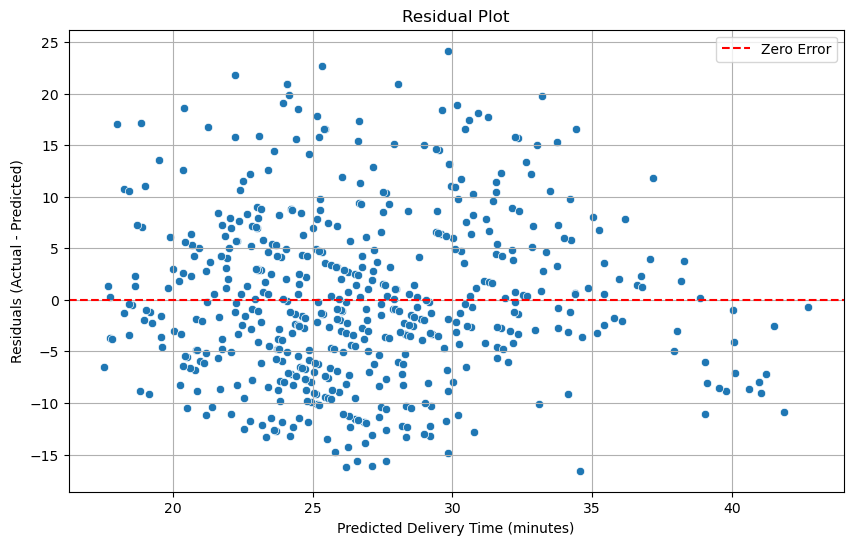

In [36]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel('Predicted Delivery Time (minutes)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.legend()
plt.grid(True)
plt.show()

- Random scatter around 0 → Good!
- Curved shape → Model might be missing non-linear patterns.
- Funnel shape → Error increases with prediction size (heteroscedasticity).
- Clusters → Model might be underfitting or missing key features


### 📊 What the residual plot shows

Plotted:
- x-axis → predicted delivery time
- y-axis → residuals (actual - predicted)
- red dashed line → zero error (perfect prediction)

The points show how far each prediction was off — above means underpredicted (actual > predicted), below means overpredicted.

### ✅ What looks good in your plot

- No clear curve or strong pattern →
That’s great! It means the model’s errors are roughly random across the prediction range, which supports the assumption of linearity.

- Roughly equal spread above and below zero →
Good again. It suggests the model is unbiased overall (it doesn’t systematically over- or under-predict).

- No obvious clustering at the extremes →
The model performs reasonably across low and mid-range delivery times.

### ⚠️ What could be improved

1. Slight funnel shape (wider spread for higher predictions) →
We can see a bit more variation in residuals around predicted delivery times above ~30 minutes.
→ This means the model may be less accurate for longer deliveries, possibly because:

The relationship between distance, traffic, or time of day and delivery time is nonlinear.

Some rare conditions (e.g., long-distance or delayed pickups) aren’t well represented in the data.

2. A few residuals above +20 or below -15 →
Those are outliers — deliveries the model couldn’t predict well.
They’re not alarming, but they’re worth checking:
    - Are they extreme distances or traffic levels?
    - Were they recorded on unusual days or with missing info?

## 🧭 What this tells us overall

✅ The residuals look reasonably good for a first linear model:
- No strong pattern → linearity assumption holds.
- Symmetric around zero → predictions are not biased.
- A bit of heteroscedasticity (spread increases for longer predictions), but not severe.

So:

“Residuals appear randomly distributed with no clear pattern, indicating the linear model’s assumptions generally hold.
Slightly higher variance at longer predicted times suggests the model could benefit from nonlinear features (e.g., interaction terms or tree-based methods) to better handle long deliveries.”

### Plot standardized residuals
Residuals tell you what kind of errors your model is making — and that tells you what to fix next.

In [ ]:
from scipy import stats
standardized_residuals = stats.zscore(residuals)
sns.scatterplot(x=y_pred, y=standardized_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.show()


### 🧩 Residual Plot Interpretation

The residual plot shows how the model’s prediction errors (`actual - predicted`) are distributed across predicted delivery times.  
Residuals appear randomly scattered around the zero line, with roughly equal spread above and below it — indicating that the **linear regression model is not strongly biased** and that the assumption of linearity is reasonably met.

However, the variance of residuals slightly increases for longer predicted delivery times (above ~30 minutes), suggesting that **the model is less accurate for longer or more complex deliveries**.  
A few points with residuals above +20 or below -15 indicate potential outliers or unusual cases (e.g., heavy traffic or long distances).

Overall, this pattern suggests that the model captures the main linear relationships but may struggle with **nonlinear effects or heteroscedasticity**.  
To improve accuracy, the next step is to **analyze standardized residuals** and consider **nonlinear models** (e.g., Random Forest or Gradient Boosting) or **feature interactions** that can better handle variable delivery conditions.


## Step 2: Improve Model Accuracy
Let’s say your residuals show a pattern — here’s how you can improve:

### A. Feature Engineering
Add features that might explain delivery time better:

In [16]:
# --- 0) Imports ---
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- 1) Start from full df and make a working copy ---
df = df_grocery.copy()

# --- 2) Parse timestamps (coerce errors to NaT) ---
# Assumes your timestamp columns are strings like 'YYYY-mm-dd HH:MM:SS'
for col in ["pickup_time", "delivery_time", "order_datetime", "pickup_datetime"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")




/var/folders/xs/pmxwbppj14b4v76l4llp17n80000gp/T/ipykernel_40075/2224817860.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], errors="coerce")


In [17]:
df[["pickup_time", "delivery_time", "order_datetime", "pickup_datetime"]].head()

,pickup_time,delivery_time,order_datetime,pickup_datetime
0,2025-11-04 15:10:00,1970-01-01 00:00:00.000000033,2022-03-01 14:55:00,2022-03-01 15:10:00
1,2025-11-04 21:45:00,1970-01-01 00:00:00.000000035,2022-03-08 21:35:00,2022-03-08 21:45:00
2,2025-11-04 17:30:00,1970-01-01 00:00:00.000000033,2022-03-14 17:25:00,2022-03-14 17:30:00
3,2025-11-04 11:00:00,1970-01-01 00:00:00.000000016,2022-02-13 10:55:00,2022-02-13 11:00:00
4,2025-11-04 10:50:00,1970-01-01 00:00:00.000000015,2022-03-07 10:40:00,2022-03-07 10:50:00


In [ ]:
# --- 3) Derive time-based features (no target leakage) ---
# pickup_hour
df["pickup_hour"] = df["pickup_time"].dt.hour

# rush-hour flag (7–9 and 17–19 inclusive)
df["is_rush_hour"] = df["pickup_hour"].between(7, 9, inclusive="both") | df["pickup_hour"].between(17, 19, inclusive="both")

# Optional: weekend flag (if you have a datetime you trust for the pickup)
df["is_weekend"] = df["pickup_time"].dt.dayofweek.isin([5, 6])

# --- 4) Target as numeric minutes: delivery_duration ---
# (delivery_time - pickup_time) in minutes
df["delivery_duration"] = (df["delivery_time"] - df["pickup_time"]).dt.total_seconds() / 60

# If you already have a numeric 'delivery_time' in minutes in your dataset, DON'T also create a datetime with same name.
# In that case, rename your numeric column (e.g., 'delivery_duration') and avoid converting it to datetime.

# --- 5) Define target & drop leakage columns from features ---
target = "delivery_duration"

# Columns that cause leakage or are not useful as raw values:
leakage_cols = [
    "delivery_time",   # raw target endpoint (datetime) -> would leak target info
    "pickup_time",     # raw start time (datetime)       -> keep only derived parts like pickup_hour
    "order_datetime",  # full timestamps -> use derived features instead
    "pickup_datetime",
]

# Build X by dropping target + leakage columns that exist
drop_cols = [c for c in ([target] + leakage_cols) if c in df.columns]
X = df.drop(columns=drop_cols)

# y must be numeric (minutes)
y = df[target]

# --- 6) Dtypes: mark categorical columns explicitly (some might be numeric codes) ---
likely_cats = [
    "weekday", "week", "vehicle", "weather", "traffic", "area",
    "category", "time_of_day", "age_group", "is_rush_hour", "is_weekend"
]
for col in likely_cats:
    if col in X.columns:
        # booleans are fine for OneHotEncoder; cast others to 'category'
        if X[col].dtype == "bool":
            pass
        else:
            X[col] = X[col].astype("category")

# --- 7) Column splits for preprocessing ---
latlon_cols = ["store_latitude", "store_longitude", "drop_latitude", "drop_longitude"]
numeric_features = X.select_dtypes(include=[np.number]).columns.difference(latlon_cols)
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns

# --- 8) Preprocess pipelines ---
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ],
    remainder="drop"
)

# --- 9) Model ---
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    n_jobs=-1
)

model = Pipeline(steps=[
    ("prep", preprocess),
    ("rf", rf)
])

# --- 10) Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# --- 11) Fit & predict ---
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# --- 12) Metrics (R², RMSE) + Baseline ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Baseline: predict the training mean duration
y_base = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_base))

# Scale-aware interpretation (based on the target's overall stats)
mean_val = y.mean()
std_val = y.std()
rng_val = y.max() - y.min()

def pct(part, whole): 
    return 100 * part / whole if whole != 0 else np.nan

print("=== Random Forest (predicting delivery_duration in minutes) ===")
print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.2f} minutes")

print("\n--- Context for RMSE ---")
print(f"RMSE as % of mean:   {pct(rmse, mean_val):.0f}%  (RMSE {rmse:.2f} / mean {mean_val:.2f})")
print(f"RMSE as % of std:    {pct(rmse, std_val):.0f}%  (RMSE {rmse:.2f} / std  {std_val:.2f})")
print(f"RMSE as % of range:  {pct(rmse, rng_val):.0f}%  (RMSE {rmse:.2f} / range {rng_val:.2f})")

print("\n--- Baseline Comparison ---")
print(f"Baseline RMSE: {baseline_rmse:.2f} minutes")
improv_minutes = baseline_rmse - rmse
improv_pct = 100 * improv_minutes / baseline_rmse
print(f"Improvement vs baseline: {improv_minutes:.2f} minutes ({improv_pct:.1f}%)")

# --- 13) (Optional) Cross-validation ---
cv_scores = cross_val_score(
    model, X, y,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1
)
print("\nCV RMSE (5-fold):")
print(f"Mean: {-cv_scores.mean():.2f}  |  Std: {cv_scores.std():.2f}")

In [ ]:
# df_grocery['is_rush_hour'] = df_grocery['pickup_hour'].between(7, 9) | df_grocery['pickup_hour'].between(17, 19)

In [ ]:
# df_grocery['pickup_hour'] = pd.to_datetime(df['pickup_time'], format='%Y-%m-%d %H:%M:%S', errors='coerce').dt.hour
# df_grocery['is_rush_hour'] = df_grocery['pickup_hour'].between(7, 9) | df_grocery['pickup_hour'].between(17, 19)

In [ ]:
# # create delivery_duration in min
# df_grocery['delivery_duration'] = (
#     pd.to_datetime(df['delivery_time'], format='%Y-%m-%d %H:%M:%S', errors='coerce') -
#     pd.to_datetime(df['pickup_time'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
# ).dt.total_seconds() / 60


In [ ]:
# df_grocery['pickup_time'] = pd.to_datetime(df['pickup_time'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
# df_grocery['delivery_time'] = pd.to_datetime(df['delivery_time'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# df_grocery['pickup_hour'] = df_grocery['pickup_time'].dt.hour

# df_grocery['delivery_duration'] = (df_grocery['delivery_time'] - df_grocery['pickup_time']).dt.total_seconds() / 60



In [ ]:
# import numpy as np
# import pandas as pd

# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.impute import SimpleImputer
# from sklearn.pipeline import Pipeline
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_squared_error, r2_score

# # ----------------------------
# # 1) Define target & features
# # ----------------------------
# target = "delivery_time"

# # Start from full df
# df = df_grocery.copy()

# # (Optional) If any obvious categorical codes are stored as integers, list them here to treat as categorical
# likely_cats = [
#     "weekday", "week", "vehicle", "weather", "traffic", "area",
#     "category", "time_of_day", "age_group"
# ]
# for col in likely_cats:
#     if col in df.columns:
#         df[col] = df[col].astype("category")

# # Split X/y
# X = df.drop(columns=[target])
# y = df[target]

# # ----------------------------
# # 2) Column splits
# # ----------------------------
# # numeric = numbers except the lat/lon columns you excluded before
# latlon_cols = ["store_latitude","store_longitude","drop_latitude","drop_longitude"]
# numeric_features = X.select_dtypes(include=[np.number]).columns.difference(latlon_cols)

# # categoricals = object/category dtypes
# categorical_features = X.select_dtypes(include=["object", "category"]).columns

# # ----------------------------
# # 3) Preprocess
# # ----------------------------
# numeric_pipe = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="median"))
# ])

# categorical_pipe = Pipeline(steps=[
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore"))
# ])

# preprocess = ColumnTransformer(
#     transformers=[
#         ("num", numeric_pipe, numeric_features),
#         ("cat", categorical_pipe, categorical_features)
#     ],
#     remainder="drop"
# )

# # ----------------------------
# # 4) Model
# # ----------------------------
# rf = RandomForestRegressor(
#     n_estimators=400,
#     random_state=42,
#     n_jobs=-1
# )

# model = Pipeline(steps=[
#     ("prep", preprocess),
#     ("rf", rf)
# ])

# # ----------------------------
# # 5) Train / Test split
# # ----------------------------
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20, random_state=42
# )

# # Fit
# model.fit(X_train, y_train)

# # Predict
# y_pred = model.predict(X_test)

# # ----------------------------
# # 6) Metrics (R², RMSE) + Baseline
# # ----------------------------
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# r2 = r2_score(y_test, y_pred)

# # Baseline: predict the training mean
# y_base = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
# baseline_rmse = np.sqrt(mean_squared_error(y_test, y_base))

# # Scale-aware interpretation
# mean_val = y.mean()
# std_val = y.std()
# rng_val = y.max() - y.min()

# def pct(part, whole): 
#     return 100 * part / whole if whole != 0 else np.nan

# print("=== Random Forest (with preprocessing) ===")
# print(f"R²:   {r2:.3f}")
# print(f"RMSE: {rmse:.2f} minutes")

# print("\n--- Context for RMSE ---")
# print(f"RMSE as % of mean:   {pct(rmse, mean_val):.0f}%  (RMSE {rmse:.2f} / mean {mean_val:.2f})")
# print(f"RMSE as % of std:    {pct(rmse, std_val):.0f}%  (RMSE {rmse:.2f} / std  {std_val:.2f})")
# print(f"RMSE as % of range:  {pct(rmse, rng_val):.0f}%  (RMSE {rmse:.2f} / range {rng_val:.2f})")

# print("\n--- Baseline Comparison ---")
# print(f"Baseline RMSE: {baseline_rmse:.2f} minutes")
# improv_minutes = baseline_rmse - rmse
# improv_pct = 100 * improv_minutes / baseline_rmse
# print(f"Improvement vs baseline: {improv_minutes:.2f} minutes ({improv_pct:.1f}%)")

# # ----------------------------
# # 7) (Optional) CV estimate
# # ----------------------------
# # Negative RMSE (scikit uses negative for losses); we negate back
# cv_scores = cross_val_score(
#     model, X, y,
#     scoring="neg_root_mean_squared_error",
#     cv=5,
#     n_jobs=-1
# )
# print("\nCV RMSE (5-fold):")
# print(f"Mean: {-cv_scores.mean():.2f}  |  Std: {cv_scores.std():.2f}")


## 2. Baseline Comparison
To compare the model to a naive baseline that always predicts the mean

In [ ]:
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print("Baseline RMSE:", baseline_rmse)
print("Model RMSE:", rmse)
print("Improvement:", baseline_rmse - rmse)
